In [68]:
from sklearn.model_selection import train_test_split
import os
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

**Обработка данных**

In [2]:
os.listdir('data/')
noise_data = 'data/dataCNNdf/test/'
ver_data_crawl = 'data/dataCNNdf/verified_data_crawl/'
ver_data = 'data/dataCNNdf/verified_data/'

video_paths = []
for folder in [noise_data, ver_data_crawl, ver_data]:
    video_paths.extend([os.path.join(folder, f) for f in os.listdir(folder)])

len(video_paths)

1571

In [3]:
paths_train, paths_test = train_test_split(video_paths, test_size=0.2, random_state=25)

len(paths_train), len(paths_test)

(1256, 315)

In [4]:
import torch

In [5]:
tensors = [torch.load(f) for f in tqdm(paths_train)]
full_tensor = torch.cat(tensors, dim=0)

print(full_tensor.shape)

100%|██████████████████████████████████████████████████████████████████████████████| 1256/1256 [00:13<00:00, 95.48it/s]

torch.Size([10651, 3, 10, 33])


In [8]:
labels_list = []

for f in paths_train:
    video_label = f.split('/')[-1].split('-')[0]
    segments = torch.load(f)
    n_segments = segments.shape[0]
    labels_list.extend([video_label for _ in range(n_segments)])

In [11]:
len(labels_list)

10651

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(labels_list)
y_train, len(y_train)

(array([7, 7, 7, ..., 9, 9, 9], dtype=int64), 10651)

In [15]:
isnan = torch.isnan(full_tensor).any().item()
isnan

False

In [16]:
tensors_test = [torch.load(f) for f in tqdm(paths_test)]
full_tensor_test = torch.cat(tensors_test, dim=0)

print(full_tensor_test.shape)

100%|████████████████████████████████████████████████████████████████████████████████| 315/315 [00:03<00:00, 88.02it/s]

torch.Size([2757, 3, 10, 33])


In [17]:
labels_list_test = []

for f in paths_test:
    video_label = f.split('/')[-1].split('-')[0]
    segments = torch.load(f)
    n_segments = segments.shape[0]
    labels_list_test.extend([video_label for _ in range(n_segments)])

In [19]:
len(labels_list_test)

2757

In [20]:
y_test = le.fit_transform(labels_list_test)
y_test, len(y_test)

(array([4, 4, 4, ..., 9, 9, 9], dtype=int64), 2757)

In [23]:
isnan = torch.isnan(full_tensor_test).any().item()
isnan

False

In [25]:
#removing face landmarks
all_landmarks = list(range(33))

drop_indices = [
    1, 2, 3,    # left_eye_inner, left_eye, left_eye_outer
    4, 5, 6,    # right_eye_inner, right_eye, right_eye_outer
    9, 10,      # mouth_left, mouth_right
]

keep_indices = [i for i in all_landmarks if i not in drop_indices]
keep_indices_tensor = torch.tensor(keep_indices)
full_tensor_filtered = full_tensor[:, :, :, keep_indices_tensor]
full_tensor_test_filtered = full_tensor_test[:, :, :, keep_indices_tensor]

full_tensor_filtered.shape, full_tensor_test_filtered.shape

(torch.Size([10651, 3, 10, 25]), torch.Size([2757, 3, 10, 25]))

**Модель CNN**

In [28]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader, TensorDataset

from tqdm import tqdm_notebook

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


In [36]:
y_tens_train = torch.tensor(y_train)
y_tens_test = torch.tensor(y_test)

y_tens_train.shape, y_tens_test.shape 

(torch.Size([10651]), torch.Size([2757]))

In [38]:
batch_size = 64
train_dataset = TensorDataset(full_tensor_filtered, y_tens_train)
test_dataset = TensorDataset(full_tensor_test_filtered, y_tens_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                         num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=4, pin_memory=True)

In [89]:
class Depthwise1x1Conv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(
            in_channels, in_channels, kernel_size,
            stride=stride, padding=padding, groups=in_channels, bias=False
        )
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
    
    def forward(self, x):
        x = self.depthwise(x)
        x = F.relu(self.bn1(x))
        x = self.pointwise(x)
        x = F.relu(self.bn2(x))
        return x

class MultiScaleTemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.branch1 = nn.Conv2d(in_channels, out_channels//3, kernel_size=3, 
                                 padding=1, dilation=1)  # local
        self.branch2 = nn.Conv2d(in_channels, out_channels//3, kernel_size=3, 
                                 padding=2, dilation=2)  # medium
        self.branch3 = nn.Conv2d(in_channels, out_channels//3, kernel_size=3, 
                                 padding=3, dilation=3)  # long
        
        self.bn1 = nn.BatchNorm2d(out_channels//3)
        self.bn2 = nn.BatchNorm2d(out_channels//3)
        self.bn3 = nn.BatchNorm2d(out_channels//3)
        
        self.mix = nn.Conv2d(out_channels, out_channels, 1)
        self.bn_mix = nn.BatchNorm2d(out_channels)
        
    def forward(self, x):
        b1 = F.relu(self.bn1(self.branch1(x)))
        b2 = F.relu(self.bn2(self.branch2(x)))
        b3 = F.relu(self.bn3(self.branch3(x)))
        
        x = torch.cat([b1, b2, b3], dim=1)
        x = self.mix(x)
        return F.relu(self.bn_mix(x))

In [90]:
class PoseClassifier(nn.Module):
    def __init__(self, n_landmarks=22, n_coords=3, seq_length=10, 
                 num_classes=22, dropout_rate=0.2):
        super().__init__()
        
        #first conv 3x3 with concat
        self.stem = MultiScaleTemporalBlock(3, 30)
        
        # Depthwise blocks
        self.block1 = Depthwise1x1Conv(30, 64, stride=1)
        self.block2 = Depthwise1x1Conv(64, 128, stride=2)
        self.block3 = Depthwise1x1Conv(128, 256, stride=2)
        self.block4 = Depthwise1x1Conv(256, 256, stride=2)
        
        # BatchNorm after residual
        # self.bn2 = nn.BatchNorm2d(64)
        # self.bn3= nn.BatchNorm2d(128)
        # self.bn4 = nn.BatchNorm2d(256)
        
        # Spatial Dropout
        self.spatial_dropout1 = nn.Dropout2d(dropout_rate)
        self.spatial_dropout2 = nn.Dropout2d(dropout_rate)
        
        # Global pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Linear1
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(256, num_classes)
        
        # Linear2
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc21 = nn.Linear(256, 128)
        self.fc22 = nn.Linear(128, num_classes)
        
        # Linear3
        self.dropout3 = nn.Dropout(dropout_rate * 1.5)
        self.fc3 = nn.Linear(256, num_classes)
        
        self._init_weights()
        
    def forward(self, x):
        # x: (batch, 3, time, landmarks)
        
        # Stem
        x = self.stem(x)  # (batch, 9, time, landmarks)
        # Blocks
        x = self.block1(x) # (batch, 32, time, landmarks)
        x = self.block2(x) # 64
        x = self.spatial_dropout1(x)
        x = self.block3(x) # 128
        x = self.block4(x) # 256
        
        # Spatial dropout
        x = self.spatial_dropout2(x)
        
        # Global pooling
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        
        # Linear
        out1 = self.dropout1(x)
        out1 = self.fc1(out1)

        out2 = self.dropout2(x)
        out2 = self.fc21(out2)
        out2 = self.fc22(out2)
        
        out3 = self.dropout3(x)
        out3 = self.fc3(out3)
        
        return (out1 + out2 + out3) / 3
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

In [96]:
def train_model(model, train_loader, val_loader, epochs=100, lr=3e-4, model_save='model/CNN_model.pth'):
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    for epoch in tqdm(range(epochs)):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
            train_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*train_correct/train_total:.2f}%'
            })
        
        train_acc = 100. * train_correct / train_total
        train_loss = train_loss / len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]')
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(device), labels.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
                val_bar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{100.*val_correct/val_total:.2f}%'
                })
        
        val_acc = 100. * val_correct / val_total
        val_loss = val_loss / len(val_loader)
        
        # Scheduler step
        scheduler.step()
        
        # History
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f'\nEpoch {epoch+1}:')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        print(f'  LR: {optimizer.param_groups[0]["lr"]:.6f}')
        
        best_val_acc = 0
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'train_acc': train_acc,
                'history': history
            }, model_save)
            print(f' model saved (val_acc: {val_acc:.2f}%)')
    
    return history

***Обучение модели и метрики***

*Первая модель*

In [70]:
model = PoseClassifier(
    n_landmarks=25,
    n_coords=3,
    seq_length=10,
    num_classes=22,
    dropout_rate=0.2
)

In [71]:
import torchsummary

torchsummary.summary(model.cuda(), (3, 10, 25))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 3, 10, 25]              84
       BatchNorm2d-2            [-1, 3, 10, 25]               6
            Conv2d-3            [-1, 3, 10, 25]              84
       BatchNorm2d-4            [-1, 3, 10, 25]               6
            Conv2d-5            [-1, 3, 10, 25]              84
       BatchNorm2d-6            [-1, 3, 10, 25]               6
            Conv2d-7            [-1, 9, 10, 25]              90
       BatchNorm2d-8            [-1, 9, 10, 25]              18
MultiScaleTemporalBlock-9            [-1, 9, 10, 25]               0
           Conv2d-10            [-1, 9, 14, 29]              81
      BatchNorm2d-11            [-1, 9, 14, 29]              18
           Conv2d-12           [-1, 32, 14, 29]             288
      BatchNorm2d-13           [-1, 32, 14, 29]              64
 Depthwise1x1Conv-14           [-1

In [72]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader
)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100 [Train]:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 1/100 [Val]:   0%|          | 0/44 [00:00<?, ?it/s]


Epoch 1:
  Train Loss: 2.8547, Train Acc: 16.71%
  Val Loss: 2.6680, Val Acc: 18.68%
  LR: 0.000300


Epoch 2/100 [Train]:   0%|          | 0/167 [00:00<?, ?it/s]

...

Epoch 99/100 [Val]:   0%|          | 0/44 [00:00<?, ?it/s]


Epoch 99:
  Train Loss: 0.2193, Train Acc: 94.02%
  Val Loss: 0.9379, Val Acc: 79.36%
  LR: 0.000000


Epoch 100/100 [Train]:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 100/100 [Val]:   0%|          | 0/44 [00:00<?, ?it/s]


Epoch 100:
  Train Loss: 0.2156, Train Acc: 94.23%
  Val Loss: 0.9430, Val Acc: 79.04%
  LR: 0.000000


Видно переобучение, повысим dropout_rate и и изменим количество параметров в модели

*Вторая модель*

In [100]:
model = PoseClassifier(
    n_landmarks=25,
    n_coords=3,
    seq_length=10,
    num_classes=22,
    dropout_rate=0.3
)

In [101]:
torchsummary.summary(model.cuda(), (3, 10, 25))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 10, 10, 25]             280
       BatchNorm2d-2           [-1, 10, 10, 25]              20
            Conv2d-3           [-1, 10, 10, 25]             280
       BatchNorm2d-4           [-1, 10, 10, 25]              20
            Conv2d-5           [-1, 10, 10, 25]             280
       BatchNorm2d-6           [-1, 10, 10, 25]              20
            Conv2d-7           [-1, 30, 10, 25]             930
       BatchNorm2d-8           [-1, 30, 10, 25]              60
MultiScaleTemporalBlock-9           [-1, 30, 10, 25]               0
           Conv2d-10           [-1, 30, 10, 25]             270
      BatchNorm2d-11           [-1, 30, 10, 25]              60
           Conv2d-12           [-1, 64, 10, 25]           1,920
      BatchNorm2d-13           [-1, 64, 10, 25]             128
 Depthwise1x1Conv-14           [-1

In [102]:
history2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader
)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100 [Train]:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 1/100 [Val]:   0%|          | 0/44 [00:00<?, ?it/s]


Epoch 1:
  Train Loss: 2.7760, Train Acc: 17.62%
  Val Loss: 2.4849, Val Acc: 25.90%
  LR: 0.000300
 model saved (val_acc: 25.90%)


Epoch 2/100 [Train]:   0%|          | 0/167 [00:00<?, ?it/s]

...

Epoch 99/100 [Val]:   0%|          | 0/44 [00:00<?, ?it/s]


Epoch 99:
  Train Loss: 0.2130, Train Acc: 93.13%
  Val Loss: 0.9275, Val Acc: 82.52%
  LR: 0.000000
 model saved (val_acc: 82.52%)


Epoch 100/100 [Train]:   0%|          | 0/167 [00:00<?, ?it/s]

Epoch 100/100 [Val]:   0%|          | 0/44 [00:00<?, ?it/s]


Epoch 100:
  Train Loss: 0.2188, Train Acc: 93.06%
  Val Loss: 0.9281, Val Acc: 82.44%
  LR: 0.000000
 model saved (val_acc: 82.44%)


In [103]:
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

In [106]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_labels = le.inverse_transform(all_labels)
y_pred_labels = le.inverse_transform(all_preds)

print(classification_report(y_test_labels, y_pred_labels))
confusion_matrix = confusion_matrix(all_labels, all_preds)

                     precision    recall  f1-score   support

barbell biceps curl       0.88      0.97      0.92       118
        bench press       0.76      0.83      0.79       130
  chest fly machine       0.82      0.91      0.86       148
           deadlift       0.77      0.79      0.78       182
decline bench press       0.82      0.78      0.80       257
        hammer curl       0.72      0.73      0.73       151
         hip thrust       0.66      0.85      0.74        84
incline bench press       0.68      0.69      0.68        78
       lat pulldown       0.69      0.85      0.76        34
      lateral raise       0.86      0.72      0.78       103
      leg extension       0.90      0.94      0.92       116
         leg raises       0.94      0.82      0.88       148
              plank       0.99      0.99      0.99       301
            pull Up       0.88      0.92      0.90       144
               push       0.92      0.92      0.92       105
  romanian deadlift    

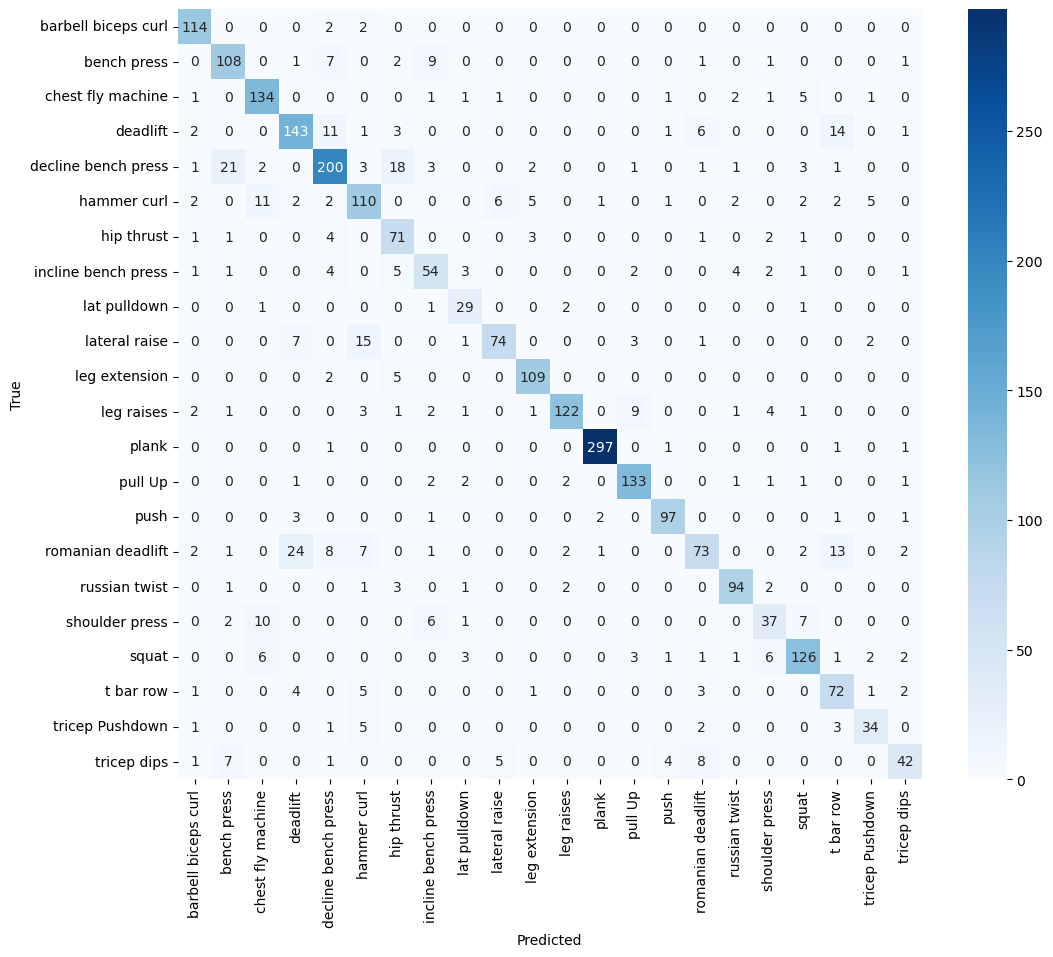

In [105]:
labels = le.classes_

plt.figure(figsize=(12,10))
sns.heatmap(confusion_matrix, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

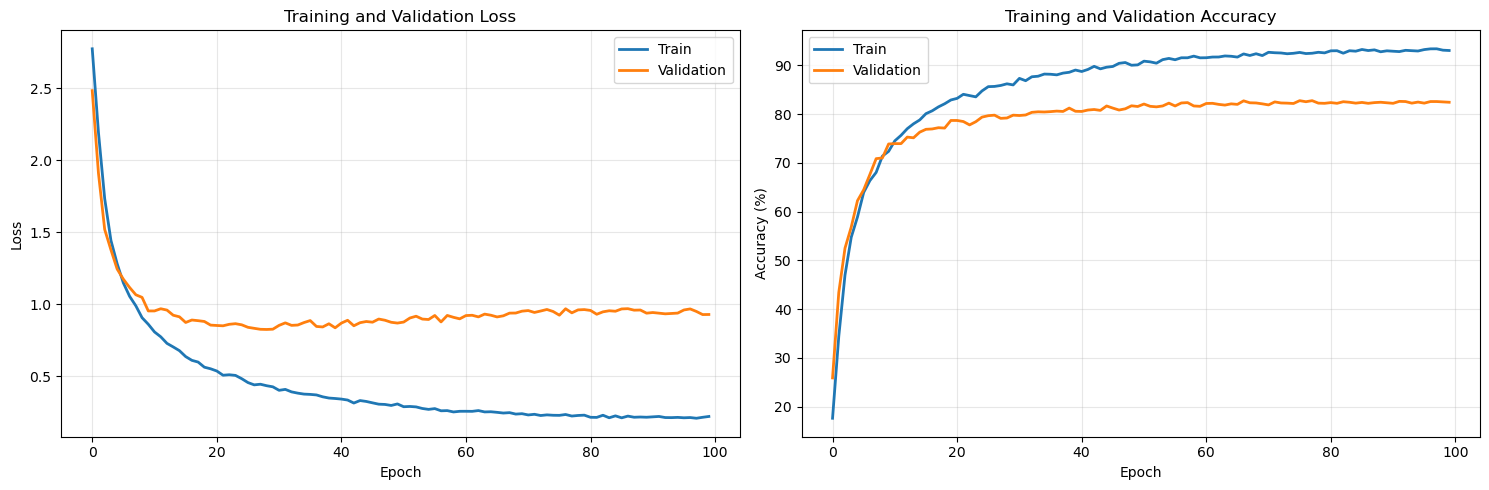

In [108]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[1].plot(history['val_acc'], label='Validation', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    plt.show()

plot_training_history(history2)